
🔹 Proyecto: Smart Hydro - Proyección Consumo Anual
🔹 Autor: Isberth Ruiz
🔹 Fecha del análisis: 2025-07-05
🔹 Código Obra: OB-0902-26
🔹 Región: La Araucanía
🔹 Comuna: Lautaro

🔸 Outliers detectados: 0


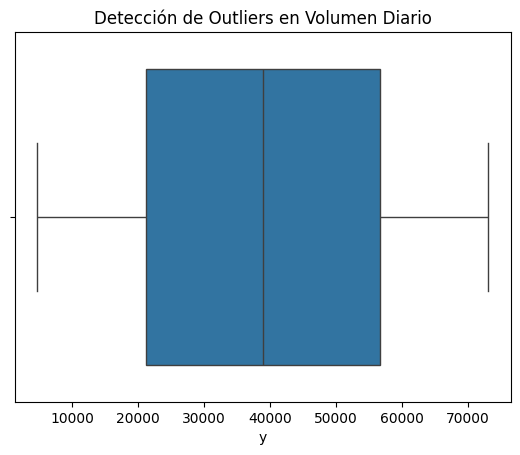

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


🌧️ Lluvia última hora: 0 mm | 🌡️ Temp: 0 °C | 💧 Humedad: 0%


DEBUG:cmdstanpy:input tempfile: /tmp/tmp3mqv_np9/xb1g3td5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3mqv_np9/l2vgedja.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=182', 'data', 'file=/tmp/tmp3mqv_np9/xb1g3td5.json', 'init=/tmp/tmp3mqv_np9/l2vgedja.json', 'output', 'file=/tmp/tmp3mqv_np9/prophet_modelkdflymub/prophet_model-20250705021727.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:17:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:17:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


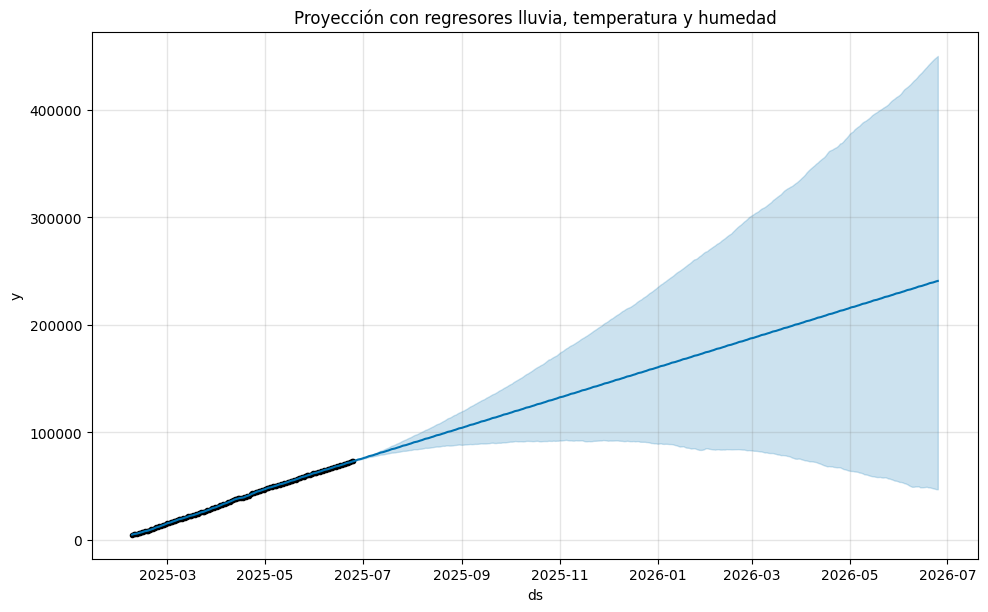

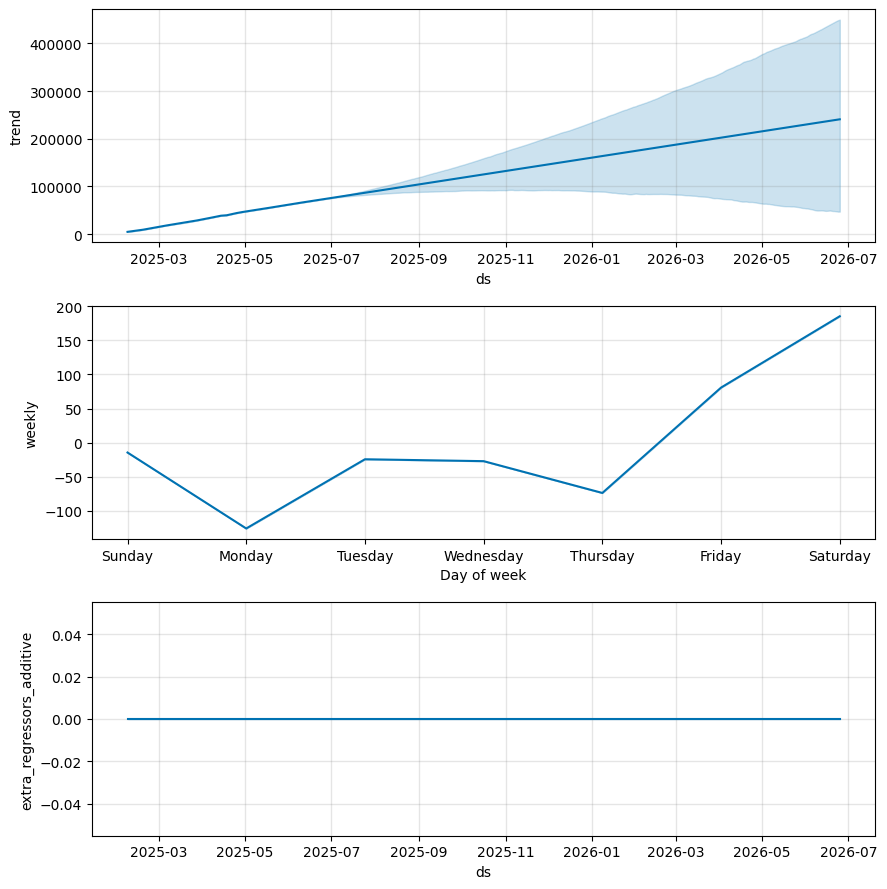

INFO:prophet:Making 2 forecasts with cutoffs between 2025-04-26 00:00:00 and 2025-05-26 00:00:00


  0%|          | 0/2 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmp3mqv_np9/dvcji_z8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3mqv_np9/ecrk7qp4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52588', 'data', 'file=/tmp/tmp3mqv_np9/dvcji_z8.json', 'init=/tmp/tmp3mqv_np9/ecrk7qp4.json', 'output', 'file=/tmp/tmp3mqv_np9/prophet_modelao6dcumg/prophet_model-20250705021728.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
02:17:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:17:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3mqv_np9/uwo2v3oy.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3mqv_np9/jkh222_h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

   horizon      mape        rmse
0   3 days  0.007053  376.832722
1   4 days  0.005832  315.753373
2   5 days  0.005348  290.270153
3   6 days  0.005428  290.714751
4   7 days  0.005445  294.938675
5   8 days  0.005303  289.830006
6   9 days  0.004922  274.602082
7  10 days  0.004287  243.952171
8  11 days  0.003216  180.855576
9  12 days  0.002516  146.054689
10 13 days  0.002457  144.210655
11 14 days  0.002743  178.908273
12 15 days  0.003089  194.618793
13 16 days  0.003419  221.558446
14 17 days  0.003631  228.819443
15 18 days  0.004308  267.386166
16 19 days  0.004628  290.225153
17 20 days  0.005306  332.367643
18 21 days  0.005781  366.419507
19 22 days  0.005896  381.588761
20 23 days  0.005975  401.695687
21 24 days  0.005979  416.109410
22 25 days  0.005993  432.249669
23 26 days  0.006073  432.865934
24 27 days  0.005946  441.475023
25 28 days  0.006311  467.110914
26 29 days  0.005858  445.114455
27 30 days  0.005362  400.503261
⚠️ Probabilidad de superar 300,000 m³: 0.00

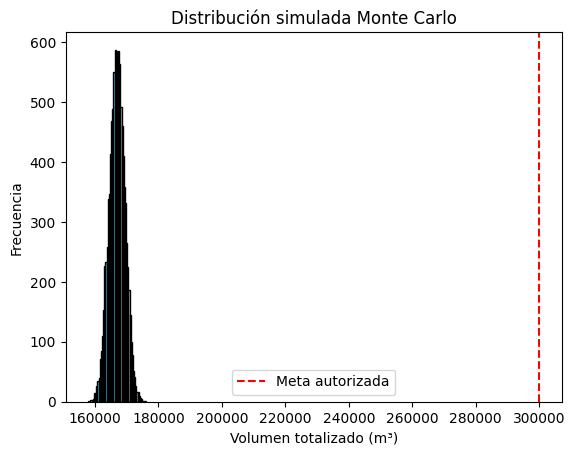


✅ Conclusión automática:
Fecha de análisis: 2025-07-05.
Volumen registrado último día: 73,150 m³.
Proyección al 31-12-2025: 240,754 m³.
Probabilidad de superar volumen autorizado (300,000 m³): 0.00 %.
MAPE validación cruzada: 0.49 % promedio.
Outliers detectados en la serie diaria: 0.

📝 Informe Word generado: informe_smart_hydro.docx


In [ ]:
# ===========================================================
# 1️⃣ METADATA DEL INFORME
# ===========================================================
import pandas as pd

proyecto = "Smart Hydro - Proyección Consumo Anual"
autor = "Isberth Ruiz", "Cristobal Yáñez"
fecha_analisis = pd.to_datetime("today").strftime("%Y-%m-%d")
codigo_obra = "OB-0902-26"
region = "La Araucanía"
comuna = "Lautaro"
volumen_maximo_autorizado = 300_000
ciudad_clima = "Lautaro,CL"
API_KEY = "TU_API_KEY"
horizonte_proyeccion_dias = 365
n_escenarios_montecarlo = 10000

print(f"""
🔹 Proyecto: {proyecto}
🔹 Autor: {autor}
🔹 Fecha del análisis: {fecha_analisis}
🔹 Código Obra: {codigo_obra}
🔹 Región: {region}
🔹 Comuna: {comuna}
""")

# ===========================================================
# 2️⃣ LIBRERÍAS
# ===========================================================
!pip install sqlalchemy psycopg2-binary prophet python-docx --quiet

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sqlalchemy import create_engine
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from docx import Document

# ===========================================================
# 3️⃣ CONEXIÓN BASE DE DATOS
# ===========================================================
username = "api"
password = "inster_api_password"
host = "db-postgresql-nyc3-22918-do-user-7500906-0.m.db.ondigitalocean.com"
port = "25060"
database = "api_telemetry"
sslmode = "require"

conn_str = f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}?sslmode={sslmode}"
engine = create_engine(conn_str)

query = """
SELECT date_time_medition, total
FROM core_interactiondetail
WHERE catchment_point_id = 1
ORDER BY date_time_medition ASC
"""
df = pd.read_sql(query, engine)

# ===========================================================
# 4️⃣ LIMPIEZA Y PREPROCESADO
# ===========================================================
df['total'] = pd.to_numeric(df['total'], errors='coerce')
df = df.dropna(subset=['total'])
df['date_time_medition'] = pd.to_datetime(df['date_time_medition']).dt.tz_localize(None)

df_daily = df.groupby(df['date_time_medition'].dt.date)['total'].max().reset_index()
df_daily.columns = ['ds', 'y']
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

# inicializamos regresores
df_daily['lluvia'] = 0
df_daily['temperatura'] = 0
df_daily['humedad'] = 0

# ===========================================================
# 5️⃣ DETECCIÓN OUTLIERS
# ===========================================================
Q1 = df_daily['y'].quantile(0.25)
Q3 = df_daily['y'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5*IQR
limite_sup = Q3 + 1.5*IQR
outliers = df_daily[(df_daily['y'] < limite_inf) | (df_daily['y'] > limite_sup)]
print(f"🔸 Outliers detectados: {len(outliers)}")

# gráfico
sns.boxplot(x=df_daily['y'])
plt.title("Detección de Outliers en Volumen Diario")
plt.show()

# ===========================================================
# 6️⃣ CONSULTA CLIMA EXTENDIDA
# ===========================================================
def get_weather_extended(city:str, api_key:str):
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric',
        'lang': 'es'
    }
    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()
        return {
            "lluvia": data.get('rain', {}).get('1h', 0),
            "temperatura": data.get('main', {}).get('temp', 0),
            "humedad": data.get('main', {}).get('humidity', 0)
        }
    except:
        return {"lluvia":0, "temperatura":0, "humedad":0}

clima = get_weather_extended(ciudad_clima, API_KEY)

df_daily.loc[df_daily.index[-1], 'lluvia'] = clima['lluvia']
df_daily.loc[df_daily.index[-1], 'temperatura'] = clima['temperatura']
df_daily.loc[df_daily.index[-1], 'humedad'] = clima['humedad']

print(f"🌧️ Lluvia última hora: {clima['lluvia']} mm | 🌡️ Temp: {clima['temperatura']} °C | 💧 Humedad: {clima['humedad']}%")

# ===========================================================
# 7️⃣ PROPHET + REGRESORES
# ===========================================================
m = Prophet()
m.add_regressor('lluvia')
m.add_regressor('temperatura')
m.add_regressor('humedad')
m.fit(df_daily)

future = m.make_future_dataframe(periods=horizonte_proyeccion_dias)
future['lluvia'] = 0
future['temperatura'] = 0
future['humedad'] = 0

forecast = m.predict(future)

fig = m.plot(forecast)
plt.title("Proyección con regresores lluvia, temperatura y humedad")
plt.show()

# análisis de componentes
fig2 = m.plot_components(forecast)
plt.show()

# ===========================================================
# 8️⃣ VALIDACIÓN CRUZADA
# ===========================================================
df_cv = cross_validation(m, initial='60 days', period='30 days', horizon='30 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mape', 'rmse']])

# ===========================================================
# 9️⃣ MONTE CARLO
# ===========================================================
media_diaria = df_daily['y'].diff().dropna().mean()
std_diaria = df_daily['y'].diff().dropna().std()

dias_restantes = (pd.to_datetime("2025-12-31") - df_daily['ds'].max()).days
volumen_actual = df_daily['y'].iloc[-1]

resultados = []
for i in range(n_escenarios_montecarlo):
    consumos = np.random.normal(loc=media_diaria, scale=std_diaria, size=dias_restantes)
    consumos = np.where(consumos < 0, 0, consumos)
    volumen_final = volumen_actual + consumos.sum()
    resultados.append(volumen_final)

prob_supera = np.mean(np.array(resultados) > volumen_maximo_autorizado) * 100
print(f"⚠️ Probabilidad de superar {volumen_maximo_autorizado:,} m³: {prob_supera:.2f}%")

plt.hist(resultados, bins=50, color="skyblue", edgecolor="black")
plt.axvline(volumen_maximo_autorizado, color="red", linestyle="--", label="Meta autorizada")
plt.title("Distribución simulada Monte Carlo")
plt.xlabel("Volumen totalizado (m³)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# ===========================================================
# 🔟 CONCLUSIONES AUTOMÁTICAS
# ===========================================================
volumen_ult_dia = df_daily['y'].iloc[-1]
volumen_proyectado = forecast['yhat'].iloc[-1]

conclusion = f"""
✅ Conclusión automática:
Fecha de análisis: {fecha_analisis}.
Volumen registrado último día: {volumen_ult_dia:,.0f} m³.
Proyección al 31-12-2025: {volumen_proyectado:,.0f} m³.
Probabilidad de superar volumen autorizado ({volumen_maximo_autorizado:,} m³): {prob_supera:.2f} %.
MAPE validación cruzada: {df_p['mape'].mean()*100:.2f} % promedio.
Outliers detectados en la serie diaria: {len(outliers)}.
"""

print(conclusion)

# ===========================================================
# 1️⃣1️⃣ EXPORTAR A WORD
# ===========================================================
doc = Document()
doc.add_heading("Informe Proyección Consumo Anual - Smart Hydro", 0)
doc.add_paragraph(conclusion)
doc.save("informe_smart_hydro.docx")
print("📝 Informe Word generado: informe_smart_hydro.docx")


⚠️ ALERTAS DE INCUMPLIMIENTO MENSUAL:
- Marzo 2025 | Consumo: 30091 m³ > cuota: 23000 m³
- Abril 2025 | Consumo: 46481 m³ > cuota: 20000 m³
- Mayo 2025 | Consumo: 61663 m³ > cuota: 18000 m³
- Junio 2025 | Consumo: 73150 m³ > cuota: 15000 m³
📝 Word con control mensual exportado: informe_smart_hydro_fase2.docx


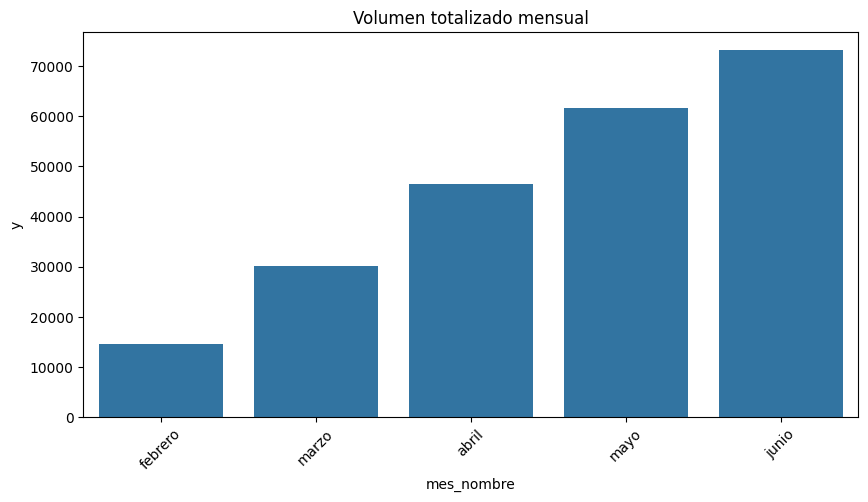

In [ ]:
# ===========================================================
# FASE 2.1 CUOTAS MENSUALES
# ===========================================================

cuotas_mensuales = {
    "enero": 25000,
    "febrero": 22000,
    "marzo": 23000,
    "abril": 20000,
    "mayo": 18000,
    "junio": 15000,
    "julio": 15000,
    "agosto": 18000,
    "septiembre": 22000,
    "octubre": 25000,
    "noviembre": 27000,
    "diciembre": 30000
}

# sumar volumen mensual actual
df_daily['mes'] = df_daily['ds'].dt.month
df_daily['anio'] = df_daily['ds'].dt.year

df_mensual = df_daily.groupby(['anio','mes'])['y'].max().reset_index()

# merge con nombre de mes
meses = {1:'enero',2:'febrero',3:'marzo',4:'abril',5:'mayo',6:'junio',7:'julio',8:'agosto',9:'septiembre',10:'octubre',11:'noviembre',12:'diciembre'}
df_mensual['mes_nombre'] = df_mensual['mes'].map(meses)

# verificación de incumplimientos
df_mensual['alerta_incumplimiento'] = df_mensual.apply(
    lambda row: row['y'] > cuotas_mensuales[row['mes_nombre']], axis=1
)

# imprimir alertas
print("⚠️ ALERTAS DE INCUMPLIMIENTO MENSUAL:")
for _, row in df_mensual[df_mensual['alerta_incumplimiento']].iterrows():
    print(f"- {row['mes_nombre'].capitalize()} {row['anio']} | Consumo: {row['y']:.0f} m³ > cuota: {cuotas_mensuales[row['mes_nombre']]:.0f} m³")

# ===========================================================
# FASE 2.2 EXPORTACIÓN AVANZADA A WORD
# ===========================================================
from docx.shared import Inches

doc.add_heading("Control de Cuotas Mensuales", level=1)
for _, row in df_mensual.iterrows():
    status = "✅" if not row['alerta_incumplimiento'] else "⚠️"
    texto = (
        f"{row['mes_nombre'].capitalize()} {row['anio']}: "
        f"{row['y']:.0f} m³ (cuota: {cuotas_mensuales[row['mes_nombre']]:,.0f}) {status}"
    )
    doc.add_paragraph(texto)

# opcionalmente agregar un gráfico como imagen
plt.figure(figsize=(10,5))
sns.barplot(x=df_mensual['mes_nombre'], y=df_mensual['y'])
plt.xticks(rotation=45)
plt.title("Volumen totalizado mensual")
plt.savefig("grafico_mensual.png", bbox_inches='tight')
doc.add_picture("grafico_mensual.png", width=Inches(5))

# guardar el word
doc.save("informe_smart_hydro_fase2.docx")
print("📝 Word con control mensual exportado: informe_smart_hydro_fase2.docx")


In [ ]:
# ============================================================
# 1️⃣ Definir cuotas mensuales
# ============================================================
cuotas_mensuales = {
    "enero": 25000,
    "febrero": 22000,
    "marzo": 23000,
    "abril": 20000,
    "mayo": 18000,
    "junio": 15000,
    "julio": 15000,
    "agosto": 18000,
    "septiembre": 22000,
    "octubre": 25000,
    "noviembre": 27000,
    "diciembre": 30000
}

# ============================================================
# 2️⃣ Procesar dataframe mensual
# ============================================================
df_daily['mes'] = df_daily['ds'].dt.month
df_daily['anio'] = df_daily['ds'].dt.year

df_mensual = df_daily.groupby(['anio', 'mes'])['y'].max().reset_index()

# nombre mes
meses = {
    1:'enero',2:'febrero',3:'marzo',4:'abril',5:'mayo',6:'junio',
    7:'julio',8:'agosto',9:'septiembre',10:'octubre',11:'noviembre',12:'diciembre'
}
df_mensual['mes_nombre'] = df_mensual['mes'].map(meses)

# cuota y cumplimiento
df_mensual['cuota'] = df_mensual['mes_nombre'].map(cuotas_mensuales)
df_mensual['cumplimiento_%'] = df_mensual['y'] / df_mensual['cuota'] * 100

# alerta
df_mensual['alerta_incumplimiento'] = df_mensual['y'] > df_mensual['cuota']

# mostrar tabla
df_mensual

# ============================================================
# 3️⃣ Plotly - gráfico mensual
# ============================================================
import plotly.express as px

fig = px.bar(
    df_mensual,
    x="mes_nombre",
    y="y",
    color="alerta_incumplimiento",
    text="cumplimiento_%",
    title="Volumen totalizado mensual vs cuota",
    labels={"y":"Volumen m³"},
    color_discrete_map={True:"red", False:"green"}
)

fig.show()

# ============================================================
# 4️⃣ Exportar Word con tabla de cuotas y gráfico HTML
# ============================================================
from docx import Document

doc = Document()
doc.add_heading("Informe Smart Hydro - Control Cuotas Mensuales", 0)

# resumen en texto
for _, row in df_mensual.iterrows():
    status = "✅" if not row['alerta_incumplimiento'] else "⚠️"
    texto = (
        f"{row['mes_nombre'].capitalize()} {row['anio']}: "
        f"{row['y']:.0f} m³ (cuota: {row['cuota']:,}) "
        f"cumplimiento: {row['cumplimiento_%']:.1f}% {status}"
    )
    doc.add_paragraph(texto)

# guardar referencia del HTML
fig.write_html("grafico_mensual.html")
doc.add_paragraph("🔎 El gráfico mensual interactivo se encuentra exportado como 'grafico_mensual.html' para consulta.")

# guardar el word
doc.save("informe_smart_hydro_cuotas.docx")
print("✅ Word exportado como informe_smart_hydro_cuotas.docx")


/usr/local/lib/python3.11/dist-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




✅ Word exportado como informe_smart_hydro_cuotas.docx


In [ ]:
# escenario what-if
media_diaria_escenario = 450   # m3/día promedio hipotético
std_diaria_escenario = 150     # m3/día dispersión hipotética

dias_restantes = (pd.to_datetime("2025-12-31") - df_daily['ds'].max()).days
volumen_actual = df_daily['y'].iloc[-1]


In [ ]:
resultados_escenario = []
for i in range(10000):
    consumos = np.random.normal(
        loc=media_diaria_escenario,
        scale=std_diaria_escenario,
        size=dias_restantes
    )
    consumos = np.where(consumos < 0, 0, consumos)
    volumen_final = volumen_actual + consumos.sum()
    resultados_escenario.append(volumen_final)

resultados_escenario = np.array(resultados_escenario)

# probabilidad
prob_supera_escenario = np.mean(resultados_escenario > volumen_maximo_autorizado) * 100
print(f"⚠️ Probabilidad de superar {volumen_maximo_autorizado:,} m³ bajo escenario what-if: {prob_supera_escenario:.2f}%")


⚠️ Probabilidad de superar 300,000 m³ bajo escenario what-if: 0.00%


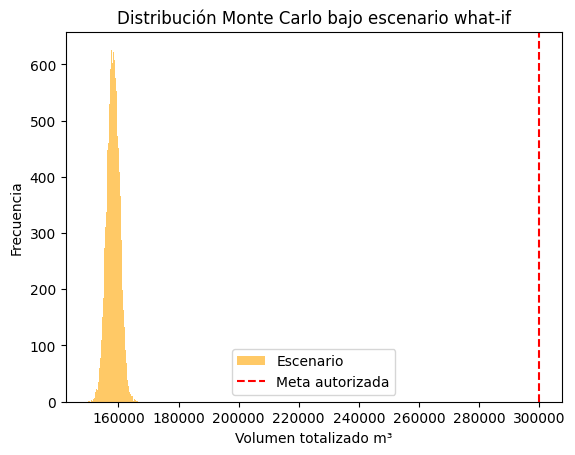

In [ ]:
import matplotlib.pyplot as plt

plt.hist(resultados_escenario, bins=50, alpha=0.6, label="Escenario", color="orange")
plt.axvline(volumen_maximo_autorizado, color="red", linestyle="--", label="Meta autorizada")
plt.title("Distribución Monte Carlo bajo escenario what-if")
plt.xlabel("Volumen totalizado m³")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


In [ ]:
texto_escenario = f"""
🟠 Escenario What-if:
- Consumo medio diario hipotético: {media_diaria_escenario} m³
- Desviación estándar diaria: {std_diaria_escenario} m³
- Probabilidad de sobrepasar {volumen_maximo_autorizado:,} m³ al 31/12/2025: {prob_supera_escenario:.2f} %
"""
print(texto_escenario)



🟠 Escenario What-if:
- Consumo medio diario hipotético: 450 m³
- Desviación estándar diaria: 150 m³
- Probabilidad de sobrepasar 300,000 m³ al 31/12/2025: 0.00 %



In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s eta 0:00:00


In [ ]:
from ipywidgets import interact, IntSlider


In [ ]:
def simulacion_whatif(media_diaria, std_diaria, n_escenarios):
    dias_restantes = (pd.to_datetime("2025-12-31") - df_daily['ds'].max()).days
    volumen_actual = df_daily['y'].iloc[-1]

    resultados = []
    for i in range(n_escenarios):
        consumos = np.random.normal(
            loc=media_diaria,
            scale=std_diaria,
            size=dias_restantes
        )
        consumos = np.where(consumos < 0, 0, consumos)
        volumen_final = volumen_actual + consumos.sum()
        resultados.append(volumen_final)

    resultados = np.array(resultados)
    prob_supera = np.mean(resultados > volumen_maximo_autorizado) * 100

    # gráfico
    plt.figure(figsize=(10,5))
    plt.hist(resultados, bins=50, alpha=0.6, color="orange")
    plt.axvline(volumen_maximo_autorizado, color="red", linestyle="--", label="Meta autorizada")
    plt.title(f"Distribución Monte Carlo\nProbabilidad de superar meta: {prob_supera:.2f}%")
    plt.xlabel("Volumen totalizado m³")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

    print(f"⚠️ Probabilidad de sobrepasar {volumen_maximo_autorizado:,} m³: {prob_supera:.2f}%")


In [ ]:
interact(
    simulacion_whatif,
    media_diaria=IntSlider(min=100, max=800, step=10, value=450, description="Media m³/día"),
    std_diaria=IntSlider(min=50, max=400, step=10, value=150, description="STD m³/día"),
    n_escenarios=IntSlider(min=1000, max=20000, step=1000, value=10000, description="Escenarios")
)


interactive(children=(IntSlider(value=450, description='Media m³/día', max=800, min=100, step=10), IntSlider(v…

<function __main__.simulacion_whatif(media_diaria, std_diaria, n_escenarios)>

In [ ]:
from docx import Document

# Crear documento
doc = Document()
doc.add_heading("Documentación Técnica - Proyecto Smart Hydro", 0)

# 1️⃣ METADATA
doc.add_heading("1. METADATA DEL INFORME", level=1)
doc.add_paragraph("""
- Proyecto: Smart Hydro - Proyección Consumo Anual
- Autor: Isberth Ruiz
- Fecha de análisis: generado automáticamente
- Código Obra: OB-0902-26
- Región: La Araucanía
- Comuna: Lautaro
- Volumen máximo autorizado anual: 300,000 m³
- Horizonte de proyección: 365 días
- Número de escenarios Monte Carlo: 10,000
""")

# 2️⃣ LIBRERÍAS
doc.add_heading("2. LIBRERÍAS UTILIZADAS", level=1)
doc.add_paragraph("""
Se utilizaron las siguientes librerías de Python:
- numpy, pandas, matplotlib, seaborn
- sqlalchemy, psycopg2
- prophet
- docx (python-docx)
- requests
- plotly (opcional para gráficos interactivos)
""")

# 3️⃣ CONEXIÓN BASE DE DATOS
doc.add_heading("3. CONEXIÓN A BASE DE DATOS", level=1)
doc.add_paragraph("""
La conexión se realiza vía SQLAlchemy a un motor PostgreSQL, con usuario 'api'
y puerto 25060. La consulta extrae lecturas de volumen totalizado desde la tabla
core_interactiondetail para el punto de captación 1.
""")

# 4️⃣ LIMPIEZA Y PREPROCESADO
doc.add_heading("4. LIMPIEZA Y PREPROCESADO", level=1)
doc.add_paragraph("""
- Se convierte la columna total a numérico y se eliminan nulos.
- Se elimina la zona horaria de la fecha de medición.
- Se agrupa a nivel diario con el volumen máximo del día, dejando columnas ds (fecha) y y (volumen).
- Se inicializan variables exógenas lluvia, temperatura y humedad en cero.
""")

# 5️⃣ DETECCIÓN OUTLIERS
doc.add_heading("5. DETECCIÓN DE OUTLIERS", level=1)
doc.add_paragraph("""
Se utilizó el método IQR (rango intercuartílico) para identificar valores atípicos
en el consumo diario. Los valores fuera de 1.5*IQR se etiquetan como outliers.
""")

# 6️⃣ CONSULTA CLIMA
doc.add_heading("6. CONSULTA DE CLIMA EN TIEMPO REAL", level=1)
doc.add_paragraph("""
La función get_weather_extended usa la API de OpenWeatherMap para obtener:
- Precipitación (lluvia)
- Temperatura
- Humedad
y actualiza la última fila del dataframe diario con esos valores.
""")

# 7️⃣ PROPHET
doc.add_heading("7. PROPHET Y REGRESORES", level=1)
doc.add_paragraph("""
Se configura el modelo Prophet agregando como regresores:
- lluvia
- temperatura
- humedad
Se entrena con la serie diaria. Luego se genera el dataframe futuro (365 días)
asumiendo clima neutro (variables exógenas en cero).
""")

# 8️⃣ VALIDACIÓN
doc.add_heading("8. VALIDACIÓN CRUZADA", level=1)
doc.add_paragraph("""
Se usa Prophet cross_validation con ventanas de 60 días iniciales,
horizonte 30 días, periodo 30 días, para evaluar la precisión (MAPE, RMSE).
""")

# 9️⃣ SIMULACIÓN MONTE CARLO
doc.add_heading("9. SIMULACIÓN MONTE CARLO", level=1)
doc.add_paragraph("""
Se estima la probabilidad de superar el volumen autorizado,
simulando 10.000 escenarios con media y desviación estándar diaria
calculadas desde la serie histórica.
""")

# FASE 2 - CONTROL DE CUOTAS
doc.add_heading("10. CONTROL DE CUOTAS MENSUALES", level=1)
doc.add_paragraph("""
Se definieron cuotas mensuales (ej. enero 25.000 m³, febrero 22.000 m³, etc)
y se agruparon los datos por mes para detectar incumplimientos.
Se genera un gráfico de barras con el consumo mensual comparado con la cuota,
coloreando en rojo los meses que superan el límite.
También se exporta un Word con el resumen de alertas y el gráfico.
""")

# FASE 3 - WHAT-IF
doc.add_heading("11. ESCENARIOS WHAT-IF", level=1)
doc.add_paragraph("""
Se incorporó una función simulacion_whatif con parámetros ajustables
(media, desviación estándar, número de escenarios) para probar
cómo variarían las probabilidades de sobrepaso en distintos escenarios.
Incluye gráfico dinámico y reporte de probabilidad.
""")

# FASE 4 - RECOMENDACIONES
doc.add_heading("12. RECOMENDACIONES FUTURAS", level=1)
doc.add_paragraph("""
- Integrar correlación histórica real de lluvias con CSV externo
- Preparar panel interactivo con Streamlit o Power BI
- Automatizar envío de reportes por email
- Incluir control de cuotas mensuales directamente en la base de datos
""")

# guardar
doc.save("documentacion_smart_hydro.docx")
print("✅ Documentación exportada como documentacion_smart_hydro.docx")


✅ Documentación exportada como documentacion_smart_hydro.docx
